In [13]:
import math
import pandas_datareader as pddatareader
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense,LSTM
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
plt.style.use('bmh')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Get csv data
df = pd.read_csv("/content/drive/MyDrive/se sem4/AI and ML/Assignment/Datasets/AAPL.csv")
df.head(6)

,Date,Open,High,Low,Close,Adj Close,Volume
0,4/1/2010,7.622500,7.660714,7.585000,7.643214,6.535084,493729600
1,5/1/2010,7.664286,7.699643,7.616071,7.656429,6.546385,601904800
2,6/1/2010,7.656429,7.686786,7.526786,7.534643,6.442255,552160000
3,7/1/2010,7.562500,7.571429,7.466071,7.520714,6.430346,477131200
4,8/1/2010,7.510714,7.571429,7.466429,7.570714,6.473097,447610800
5,11/1/2010,7.600000,7.607143,7.444643,7.503929,6.415995,462229600


In [4]:
#get rows and columns in data set
df.shape

(3155, 7)

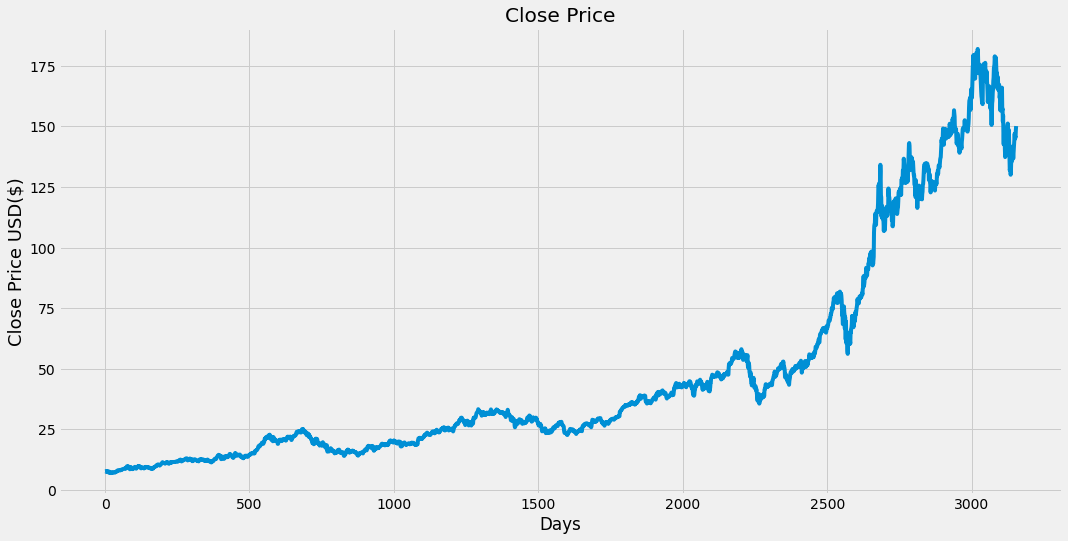

In [5]:
#Visualize closing price history
plt.figure(figsize=(16,8))
y = []
for i in range(0,12):
  y.append(2010+i)
plt.title('Close Price')
plt.plot(df['Close'])
plt.xlabel('Days')
plt.ylabel('Close Price USD($)', fontsize=18)
plt.show()

In [6]:
#Create a new dataframe with only the close column
df = df[['Close']]
df.head(5)

,Close
0,7.643214
1,7.656429
2,7.534643
3,7.520714
4,7.570714


In [7]:
#Create a variable to predict the 'x' days out into the future
future_days = 30
#create new column(target) shifted 'x' units/days up
df['Prediction'] = df[['Close']].shift(-future_days)
df.tail(4)

,Close,Prediction
3151,145.860001,NaN
3152,145.490005,NaN
3153,148.470001,NaN
3154,150.169998,NaN


In [9]:
#Create the feature data set(X) and convert it to a numpy array and remove the last 'x' rows/days
X = np.array(df.drop(['Prediction'],1))[:-future_days]
print(X)

[[  7.643214]
 [  7.656429]
 [  7.534643]
 ...
 [149.639999]
 [148.839996]
 [148.710007]]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


In [10]:
#Create the target data set(y) and convert it to a numpy array
y = np.array(df['Prediction'])[:-future_days]
print(y)

[  7.233929   7.2475     7.2025   ... 145.490005 148.470001 150.169998]


In [14]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.25)

In [15]:
#create models
#create decision tree regressor model
tree = DecisionTreeRegressor().fit(x_train,y_train)
#Create the linear regression model
lr = LinearRegression().fit(x_train,y_train)

In [17]:
#get last 'x' rows of the feature data set
x_future = df.drop(['Prediction'],1)[:-future_days]
x_future = x_future.tail(future_days)
x_future = np.array(x_future)
x_future

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


array([[167.229996],
       [166.419998],
       [161.789993],
       [162.880005],
       [156.800003],
       [156.570007],
       [163.639999],
       [157.649994],
       [157.960007],
       [159.479996],
       [166.020004],
       [156.770004],
       [157.279999],
       [152.059998],
       [154.509995],
       [146.5     ],
       [142.559998],
       [147.110001],
       [145.539993],
       [149.240005],
       [140.820007],
       [137.350006],
       [137.589996],
       [143.110001],
       [140.360001],
       [140.520004],
       [143.779999],
       [149.639999],
       [148.839996],
       [148.710007]])

In [18]:
#Show model(tree prediction)
tree_prediction = tree.predict(x_future)
print(tree_prediction)
print()
#Show linear regression prediction model
lr_prediction = lr.predict(x_future)
print(lr_prediction)

[151.210007 145.380005 146.139999 148.710007 147.960007 142.639999
 173.070007 167.229996 167.229996 135.429993 130.059998 147.960007
 135.869995 135.350006 138.270004 141.660004 141.660004 137.440002
 139.229996 136.720001 161.940002 141.559998 119.989998 146.350006
 147.039993 147.039993 145.860001 145.490005 174.559998 150.169998]

[169.23524825 168.4199063  163.75935492 164.85655826 158.73644355
 158.50493016 165.6215663  159.59204235 159.90410066 161.43411776
 168.01727335 158.70624663 159.21960632 153.96516645 156.43132727
 148.36848647 144.40249037 148.98251194 147.40214584 151.1265686
 142.65101981 139.15812554 139.39969887 144.95612201 142.18797893
 142.34903755 145.63054031 151.52920155 150.72392055 150.59307395]


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


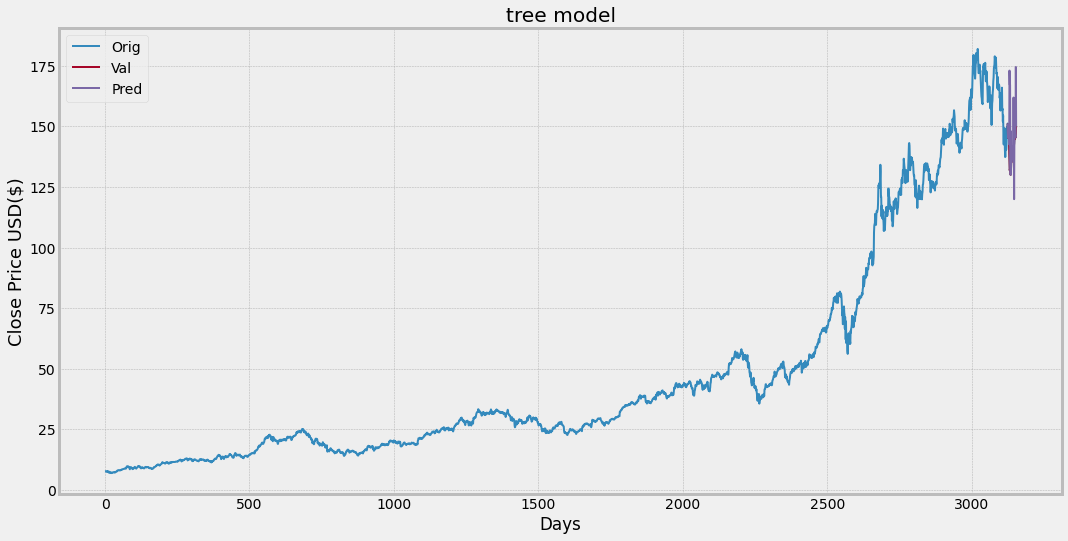

In [20]:
#Visual the data
predictions = tree_prediction
valid = df[X.shape[0]:]
valid['Predictions'] = predictions
plt.figure(figsize=(16,8))
plt.title('tree model')
plt.xlabel('Days')
plt.ylabel('Close Price USD($)', fontsize=18)
plt.plot(df['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Orig', 'Val', 'Pred'])
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


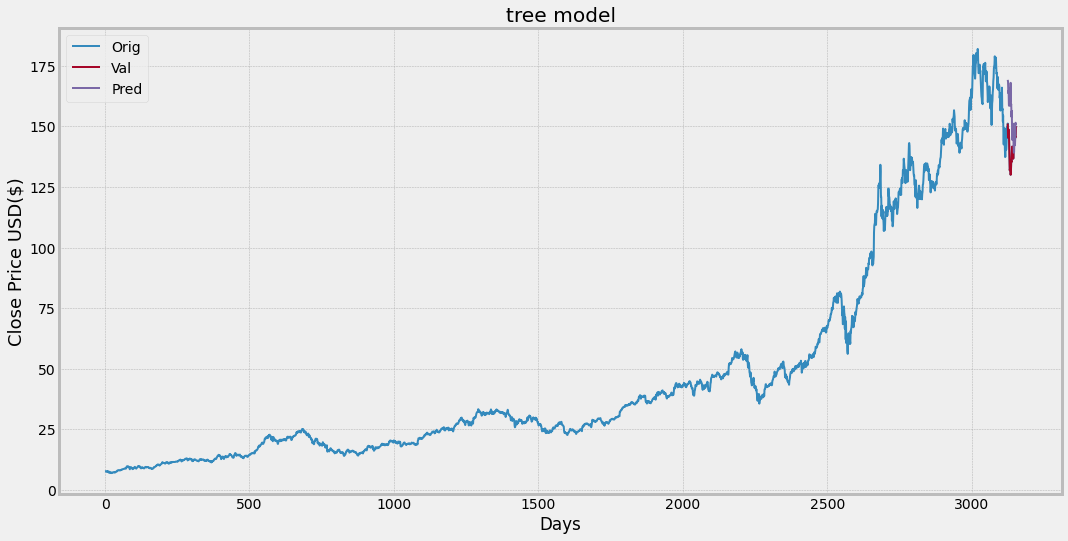

In [21]:
#Visual the linear regression data
predictions = lr_prediction
valid = df[X.shape[0]:]
valid['Predictions'] = predictions
plt.figure(figsize=(16,8))
plt.title('tree model')
plt.xlabel('Days')
plt.ylabel('Close Price USD($)', fontsize=18)
plt.plot(df['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Orig', 'Val', 'Pred'])
plt.show()